In [49]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
data = pd.read_csv("./loan_approval_data.csv")
# data.head()

# Handle missing values

In [51]:
# to select colunms based on type we use dtypes
categorical_cols = data.select_dtypes(include=["object"]).columns
numerical_cols = data.select_dtypes(include=["number"]).columns

In [52]:
from sklearn.impute import SimpleImputer
num_imp = SimpleImputer(strategy='mean');
data[numerical_cols] = num_imp.fit_transform(data[numerical_cols])
data.sample(10)

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
705,706.0,9943.000000,1177.0,Contract,23.0,Single,1.0,690.000000,4.000000,0.130000,2409.000000,18886.0,20675.0,60.0,Car,Semiurban,Not Graduate,Male,Private,Yes
365,366.0,16069.000000,3155.0,Contract,47.0,Married,2.0,762.000000,4.000000,0.347263,8708.000000,49163.0,29016.0,60.0,Business,Semiurban,Graduate,Male,Unemployed,Yes
398,399.0,13261.000000,6342.0,Salaried,50.0,Single,0.0,606.000000,3.000000,0.490000,13746.000000,45210.0,39311.0,24.0,Business,Rural,NaN,Female,Unemployed,No
642,643.0,5900.000000,5238.0,Self-employed,34.0,Married,2.0,711.000000,1.950526,0.347263,14691.000000,43481.0,38834.0,84.0,Business,Semiurban,Graduate,Female,NaN,No
828,829.0,4243.000000,7397.0,Salaried,42.0,Married,2.0,672.000000,3.000000,0.510000,9940.452632,4327.0,39255.0,60.0,Home,Urban,Graduate,Male,Business,No
258,259.0,5420.000000,7291.0,Salaried,53.0,Married,0.0,676.033684,2.000000,0.270000,8186.000000,5289.0,8470.0,12.0,Business,Rural,Graduate,Female,Government,Yes
187,188.0,16257.000000,3430.0,NaN,58.0,Married,0.0,676.033684,2.000000,0.390000,5591.000000,15945.0,5694.0,72.0,Car,Semiurban,Graduate,Male,MNC,No
841,842.0,10852.571579,9686.0,Salaried,40.0,Single,1.0,643.000000,3.000000,0.550000,1843.000000,43798.0,33535.0,60.0,NaN,Urban,Not Graduate,Male,Government,No
388,389.0,5913.000000,5179.0,Unemployed,39.0,Single,1.0,739.000000,2.000000,0.130000,3367.000000,24036.0,1730.0,60.0,Education,Urban,Graduate,Female,Private,Yes
507,508.0,13704.000000,2920.0,Salaried,24.0,Married,0.0,695.000000,2.000000,0.310000,4833.000000,30916.0,21594.0,60.0,Car,Urban,Graduate,Female,MNC,Yes


In [53]:
cat_imp = SimpleImputer(strategy='most_frequent')
data[categorical_cols] = cat_imp.fit_transform(data[categorical_cols])
# data.sample(10)
# data.isnull().sum()

# EDA

Loan_Approved
No     702
Yes    298
Name: count, dtype: int64


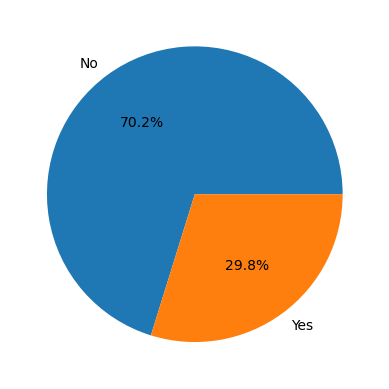

In [54]:
target_class = data["Loan_Approved"].value_counts()
print(target_class)

plt.pie(target_class,labels=["No","Yes"],autopct='%1.1f%%')
plt.show()

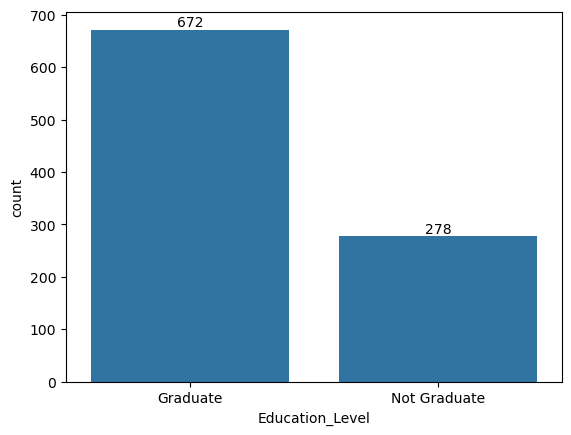

In [14]:
# Analyze Categories
# gender_cnt = data["Gender"].value_counts();
# ax = sns.barplot(gender_cnt)
# ax.bar_label(ax.containers[0]);
# Analyze Categories
edu_cnt = data["Education_Level"].value_counts();
ax = sns.barplot(edu_cnt)
ax.bar_label(ax.containers[0]);

<Axes: xlabel='Applicant_Income', ylabel='Count'>

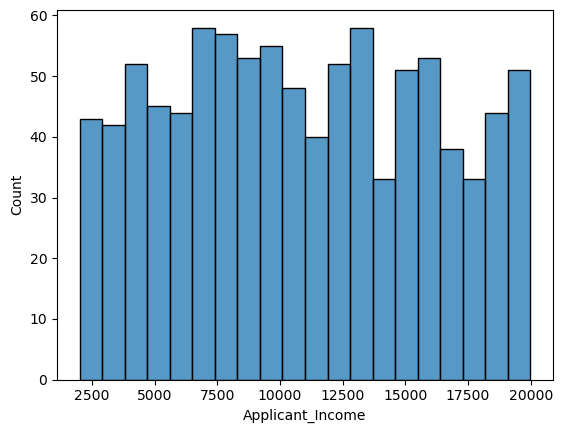

In [17]:
sns.histplot(
    data = data,
    x = "Applicant_Income",
    bins=20
)

<Axes: xlabel='Coapplicant_Income', ylabel='Count'>

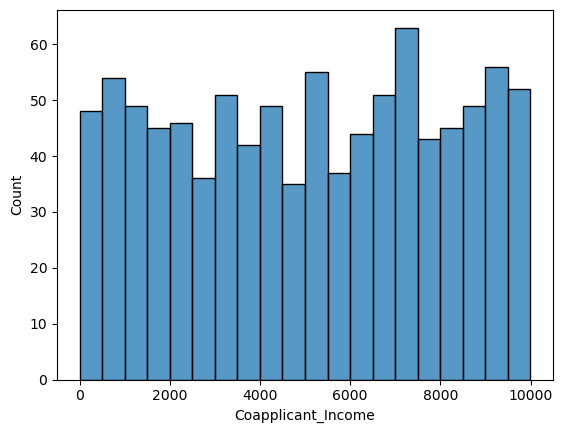

In [18]:
sns.histplot(
    data = data,
    x = "Coapplicant_Income",
    bins=20
)

<Axes: xlabel='Loan_Approved', ylabel='Applicant_Income'>

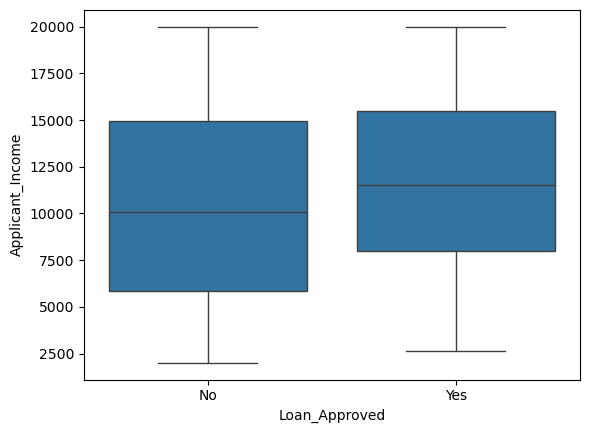

In [19]:
#outlier - boxplot

sns.boxplot(
    data = data,
    x="Loan_Approved",
    y="Applicant_Income",
)

<Axes: xlabel='Credit_Score', ylabel='Count'>

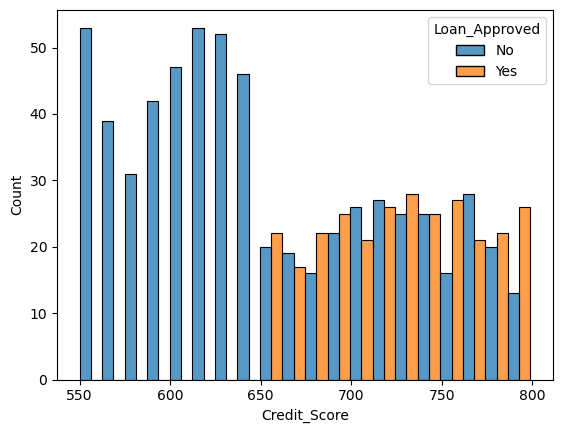

In [22]:
#credit score with loan_Approved

sns.histplot(
    data=data,
    x="Credit_Score",
    hue="Loan_Approved",
    bins=20,
    multiple = "dodge"
)

<Axes: xlabel='Applicant_Income', ylabel='Count'>

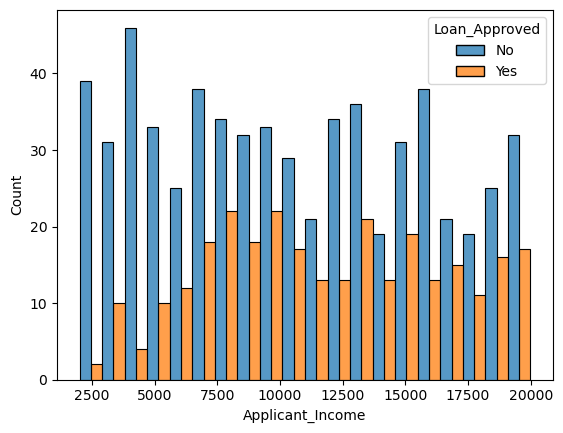

In [23]:
sns.histplot(
    data=data,
    x="Applicant_Income",
    hue="Loan_Approved",
    bins=20,
    multiple = "dodge"
)

In [92]:
# Remove Applicant Id
# data = data.drop("Applicant_ID",axis=1)
data.sample(20)

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
439,6171.0,5791.0,23.000000,1.0,779.0,2.0,0.57,526.000000,49725.000000,39413.000000,...,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0
839,5756.0,9424.0,49.000000,1.0,705.0,1.0,0.56,11228.000000,24802.792632,34800.000000,...,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
809,14790.0,5699.0,32.000000,2.0,601.0,0.0,0.22,9940.452632,41881.000000,18326.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
942,7797.0,1884.0,21.000000,3.0,559.0,0.0,0.18,17675.000000,37924.000000,20522.825263,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
77,17422.0,7617.0,48.000000,2.0,581.0,4.0,0.46,11936.000000,7910.000000,8145.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
364,7881.0,1823.0,40.000000,1.0,579.0,0.0,0.47,8864.000000,39695.000000,20522.825263,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
869,7959.0,4895.0,40.000000,2.0,764.0,2.0,0.13,15355.000000,7187.000000,11402.000000,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
602,8949.0,6262.0,52.000000,0.0,766.0,4.0,0.35,7145.000000,21740.000000,25474.000000,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
630,13637.0,891.0,35.000000,2.0,792.0,1.0,0.42,1909.000000,34964.000000,10759.000000,...,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
493,3214.0,3638.0,41.000000,1.0,779.0,3.0,0.13,1883.000000,13782.000000,6950.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [56]:
data.columns
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_Income    1000 non-null   float64
 1   Coapplicant_Income  1000 non-null   float64
 2   Employment_Status   1000 non-null   object 
 3   Age                 1000 non-null   float64
 4   Marital_Status      1000 non-null   object 
 5   Dependents          1000 non-null   float64
 6   Credit_Score        1000 non-null   float64
 7   Existing_Loans      1000 non-null   float64
 8   DTI_Ratio           1000 non-null   float64
 9   Savings             1000 non-null   float64
 10  Collateral_Value    1000 non-null   float64
 11  Loan_Amount         1000 non-null   float64
 12  Loan_Term           1000 non-null   float64
 13  Loan_Purpose        1000 non-null   object 
 14  Property_Area       1000 non-null   object 
 15  Education_Level     1000 non-null   object 
 16  Gender 

In [57]:
from sklearn.preprocessing import LabelEncoder,OneHotEncoder
le = LabelEncoder()
data["Education_Level"] = le.fit_transform(data["Education_Level"]);
data["Loan_Approved"] = le.fit_transform(data["Loan_Approved"]);
data.head()


,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,1,Female,Private,0
1,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,0,Male,Private,0
2,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,0,Female,Government,1
3,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,0,Female,Government,0
4,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,0,Male,Private,1


In [60]:
cols = [
    "Employment_Status","Marital_Status","Loan_Purpose",
    "Property_Area","Gender","Employer_Category"
]

ohe = OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore")

encoded = ohe.fit_transform(data[cols])

encoded_data = pd.DataFrame(
    encoded,
    columns=ohe.get_feature_names_out(cols),
    index=data.index
)

data = pd.concat([data.drop(columns=cols), encoded_data], axis=1)
# data.head()

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
0,17795.0,1387.0,51.0,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,2860.0,2679.0,46.0,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
2,7390.0,2106.0,25.0,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
3,13964.0,8173.0,40.0,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,13284.0,4223.0,31.0,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0


In [61]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 28 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Applicant_Income                 1000 non-null   float64
 1   Coapplicant_Income               1000 non-null   float64
 2   Age                              1000 non-null   float64
 3   Dependents                       1000 non-null   float64
 4   Credit_Score                     1000 non-null   float64
 5   Existing_Loans                   1000 non-null   float64
 6   DTI_Ratio                        1000 non-null   float64
 7   Savings                          1000 non-null   float64
 8   Collateral_Value                 1000 non-null   float64
 9   Loan_Amount                      1000 non-null   float64
 10  Loan_Term                        1000 non-null   float64
 11  Education_Level                  1000 non-null   int64  
 12  Loan_Approved        

In [67]:
nums_cols = data.select_dtypes(include="number")
corr_matrix = nums_cols.corr()
# corr_matrix
nums_cols.corr()["Loan_Approved"].sort_values(ascending=False)

Loan_Approved                      1.000000
Credit_Score                       0.451175
Applicant_Income                   0.119796
Employer_Category_MNC              0.069049
Loan_Purpose_Personal              0.034043
Marital_Status_Single              0.030182
Property_Area_Urban                0.025963
Collateral_Value                   0.021868
Coapplicant_Income                 0.004230
Loan_Purpose_Home                  0.002118
Employment_Status_Self-employed   -0.001337
Employer_Category_Private         -0.003347
Property_Area_Semiurban           -0.012967
Savings                           -0.013437
Loan_Purpose_Education            -0.016684
Employer_Category_Unemployed      -0.021468
Age                               -0.022343
Dependents                        -0.023811
Existing_Loans                    -0.034794
Employer_Category_Government      -0.039187
Employment_Status_Salaried        -0.041428
Employment_Status_Unemployed      -0.044464
Education_Level                 

In [ ]:
plt.figure(figsize=(15, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

<Axes: >

In [71]:
X = data.drop("Loan_Approved",axis=1)
y = data["Loan_Approved"]
# X.head()

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
0,17795.0,1387.0,51.0,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,2860.0,2679.0,46.0,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
2,7390.0,2106.0,25.0,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
3,13964.0,8173.0,40.0,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,13284.0,4223.0,31.0,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0


In [72]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [74]:
from sklearn.preprocessing import StandardScaler;
scaler = StandardScaler()
x_train_scaled=scaler.fit_transform(X_train)
x_test_scaled = scaler.transform(X_test)

# Train and Evaluate Models

In [89]:
#Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,precision_score,confusion_matrix,f1_score,recall_score
log_model = LogisticRegression();
log_model.fit(x_train_scaled,y_train)
y_pred = log_model.predict(x_test_scaled)

#Evaluation
print("Logistic Regression");
print("Precision score:",precision_score(y_test,y_pred));
print("Recall score:",recall_score(y_test,y_pred));
print("f1 score:",f1_score(y_test,y_pred));
print("Accuracy score:",accuracy_score(y_test,y_pred));
print("confusion matrix:",confusion_matrix(y_test,y_pred));

Logistic Regression
Precision score: 0.7833333333333333
Recall score: 0.7704918032786885
f1 score: 0.7768595041322314
Accuracy score: 0.865
confusion matrix: [[126  13]
 [ 14  47]]


In [90]:
#KNN 
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,precision_score,confusion_matrix,f1_score,recall_score
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(x_train_scaled,y_train)
y_pred = knn_model.predict(x_test_scaled)

#Evaluation
print("KNN");
print("Precision score:",precision_score(y_test,y_pred));
print("Recall score:",recall_score(y_test,y_pred));
print("f1 score:",f1_score(y_test,y_pred));
print("Accuracy score:",accuracy_score(y_test,y_pred));
print("confusion matrix:",confusion_matrix(y_test,y_pred));

KNN
Precision score: 0.6274509803921569
Recall score: 0.5245901639344263
f1 score: 0.5714285714285714
Accuracy score: 0.76
confusion matrix: [[120  19]
 [ 29  32]]


In [114]:
#Navie Bayes 
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score,precision_score,confusion_matrix,f1_score,recall_score
nb_model = GaussianNB()
nb_model.fit(x_train_scaled,y_train)
y_pred = nb_model.predict(x_test_scaled)

#Evaluation
print("Navie Bayes");
print("Precision score:",precision_score(y_test,y_pred));
print("Recall score:",recall_score(y_test,y_pred));
print("f1 score:",f1_score(y_test,y_pred));
print("Accuracy score:",accuracy_score(y_test,y_pred));
print("confusion matrix: \n ",confusion_matrix(y_test,y_pred));

Navie Bayes
Precision score: 0.8035714285714286
Recall score: 0.7377049180327869
f1 score: 0.7692307692307693
Accuracy score: 0.865
confusion matrix: 
  [[128  11]
 [ 16  45]]


# Best Model is Navie Bayes